## Trazendo o Excel para o vscode 

In [1]:
import os

# Criar a pasta DataScience-COMPET/dataset
os.makedirs('DataScience-COMPET/dataset', exist_ok=True)
print("Pasta 'DataScience-COMPET/dataset' criada ou já existente.")

# Verificar se o arquivo existe no diretório atual
arquivo_origem = 'DSU_BRASIL_REGIOES_UFS_2024.xlsx'
arquivo_destino = 'DataScience-COMPET/dataset/DSU_BRASIL_REGIOES_UFS_2024.xlsx'

if os.path.exists(arquivo_origem):
    # Mover o arquivo para a pasta
    os.rename(arquivo_origem, arquivo_destino)
    print(f"Arquivo '{arquivo_origem}' movido para '{arquivo_destino}' com sucesso.")
else:
    print(f"Erro: O arquivo '{arquivo_origem}' não foi encontrado no diretório atual.")
    print("Por favor, faça o upload do arquivo para o Google Colab usando o painel lateral ou o código abaixo:")
    print("""
    from google.colab import files
    uploaded = files.upload()
    """)

Pasta 'DataScience-COMPET/dataset' criada ou já existente.
Erro: O arquivo 'DSU_BRASIL_REGIOES_UFS_2024.xlsx' não foi encontrado no diretório atual.
Por favor, faça o upload do arquivo para o Google Colab usando o painel lateral ou o código abaixo:

    from google.colab import files
    uploaded = files.upload()
    


## Instalando dependencias


In [18]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\gabri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import openpyxl
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Executando o Código

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [8]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Leitura do arquivo Excel, pulando as primeiras 9 linhas e usando a linha 10 (índice 9) como cabeçalho
df = pd.read_excel('./dataset/DSU_BRASIL_REGIOES_UFS_2024.xlsx', skiprows=9)

# Verificar o número de colunas e os nomes
print("Número de colunas:", len(df.columns))
print("Nomes das colunas:", df.columns.tolist())

Número de colunas: 14
Nomes das colunas: ['NU_ANO_CENSO', 'UNIDGEO', 'NO_CATEGORIA', 'NO_DEPENDENCIA', 'ED_INF_CAT_0', 'CRE_CAT_0', 'PRE_CAT_0', 'FUN_CAT_0', 'FUN_AI_CAT_0', 'FUN_AF_CAT_0', 'MED_CAT_0', 'PROF_CAT_0', 'EJA_CAT_0', 'EDU_BAS_CAT_0']


In [9]:
# Renomeando as colunas (14 colunas)
df.columns = [
    'Ano', 'Unidade_Geografica', 'Localizacao', 'Dependencia_Administrativa',
    'Educacao_Infantil_Total', 'Educacao_Infantil_Creche', 'Educacao_Infantil_PreEscola',
    'Ensino_Fundamental_Total', 'Ensino_Fundamental_Anos_Iniciais', 'Ensino_Fundamental_Anos_Finais',
    'Ensino_Medio', 'Educacao_Profissional', 'Educacao_Jovens_Adultos_EJA', 'Educacao_Especial'
]

# Selecionando colunas relevantes
df = df[[
    'Ano', 'Unidade_Geografica', 'Localizacao', 'Dependencia_Administrativa',
    'Educacao_Infantil_Total', 'Educacao_Infantil_Creche', 'Educacao_Infantil_PreEscola',
    'Ensino_Fundamental_Total', 'Ensino_Fundamental_Anos_Iniciais', 'Ensino_Fundamental_Anos_Finais',
    'Ensino_Medio', 'Educacao_Profissional', 'Educacao_Jovens_Adultos_EJA', 'Educacao_Especial'
]]

# Substituindo "-" por NaN e convertendo colunas numéricas
df = df.replace('-', pd.NA)
numeric_columns = ['Educacao_Infantil_Total', 'Educacao_Infantil_Creche', 'Educacao_Infantil_PreEscola',
                   'Ensino_Fundamental_Total', 'Ensino_Fundamental_Anos_Iniciais', 'Ensino_Fundamental_Anos_Finais',
                   'Ensino_Medio', 'Educacao_Profissional', 'Educacao_Jovens_Adultos_EJA', 'Educacao_Especial']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Tratando valores nulos (preenchendo com 0)
df[numeric_columns] = df[numeric_columns].fillna(0)

# Visualizando o DataFrame após data wrangling
print("DataFrame após data wrangling:")
print(df.head(10))

DataFrame após data wrangling:
    Ano Unidade_Geografica Localizacao Dependencia_Administrativa  \
0  2024             Brasil       Total                      Total   
1  2024             Brasil       Total                    Federal   
2  2024             Brasil       Total                   Estadual   
3  2024             Brasil       Total                  Municipal   
4  2024             Brasil       Total                    Privada   
5  2024             Brasil       Total                    Pública   
6  2024             Brasil      Urbana                      Total   
7  2024             Brasil      Urbana                    Federal   
8  2024             Brasil      Urbana                   Estadual   
9  2024             Brasil      Urbana                  Municipal   

   Educacao_Infantil_Total  Educacao_Infantil_Creche  \
0                     82.4                      81.4   
1                     89.3                      87.7   
2                     77.9               

# Interpretação de infor() e describe()

In [10]:
# Informações sobre o conjunto de dados
print("\nInformações do DataFrame:")
print(df.info())

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
print(df.describe())


Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Ano                               589 non-null    object 
 1   Unidade_Geografica                588 non-null    object 
 2   Localizacao                       588 non-null    object 
 3   Dependencia_Administrativa        588 non-null    object 
 4   Educacao_Infantil_Total           590 non-null    float64
 5   Educacao_Infantil_Creche          590 non-null    float64
 6   Educacao_Infantil_PreEscola       590 non-null    float64
 7   Ensino_Fundamental_Total          590 non-null    float64
 8   Ensino_Fundamental_Anos_Iniciais  590 non-null    float64
 9   Ensino_Fundamental_Anos_Finais    590 non-null    float64
 10  Ensino_Medio                      590 non-null    float64
 11  Educacao_Profissional             590 non-nu

# Operações de Agregação com groupby

In [11]:
# Média do percentual total por Unidade Geográfica (focando em Brasil e regiões)
media_por_regiao = df[df['Unidade_Geografica'].isin(['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']) &
                      (df['Localizacao'] == 'Total') &
                      (df['Dependencia_Administrativa'] == 'Total')].groupby('Unidade_Geografica')['Educacao_Infantil_Total'].mean()
print("\nMédia do percentual total de docentes com curso superior por região:")
print(media_por_regiao)

# Média por Dependência Administrativa (no Brasil, localização total)
media_por_dep = df[(df['Unidade_Geografica'] == 'Brasil') &
                   (df['Localizacao'] == 'Total')].groupby('Dependencia_Administrativa')['Educacao_Infantil_Total'].mean()
print("\nMédia do percentual total por dependência administrativa (Brasil):")
print(media_por_dep)

# Média do Ensino Médio por Localização (no Brasil)
media_por_loc = df[(df['Unidade_Geografica'] == 'Brasil')].groupby('Localizacao')['Ensino_Medio'].mean()
print("\nMédia do percentual no Ensino Médio por localização (Brasil):")
print(media_por_loc)


Média do percentual total de docentes com curso superior por região:
Unidade_Geografica
Brasil          82.4
Centro-Oeste    91.6
Nordeste        71.6
Norte           82.4
Sudeste         85.9
Sul             84.5
Name: Educacao_Infantil_Total, dtype: float64

Média do percentual total por dependência administrativa (Brasil):
Dependencia_Administrativa
Estadual     77.9
Federal      89.3
Municipal    86.7
Privada      71.2
Pública      86.7
Total        82.4
Name: Educacao_Infantil_Total, dtype: float64

Média do percentual no Ensino Médio por localização (Brasil):
Localizacao
Rural     90.550000
Total     96.100000
Urbana    96.833333
Name: Ensino_Medio, dtype: float64


# Visualizações

Matplotlib is building the font cache; this may take a moment.


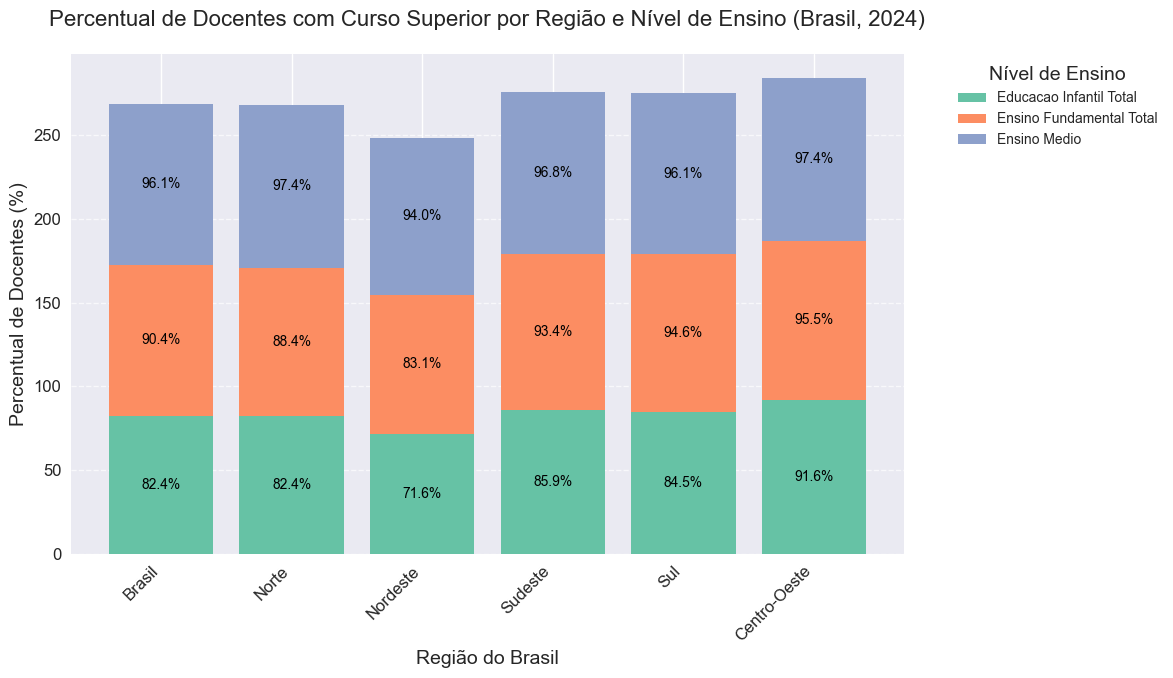

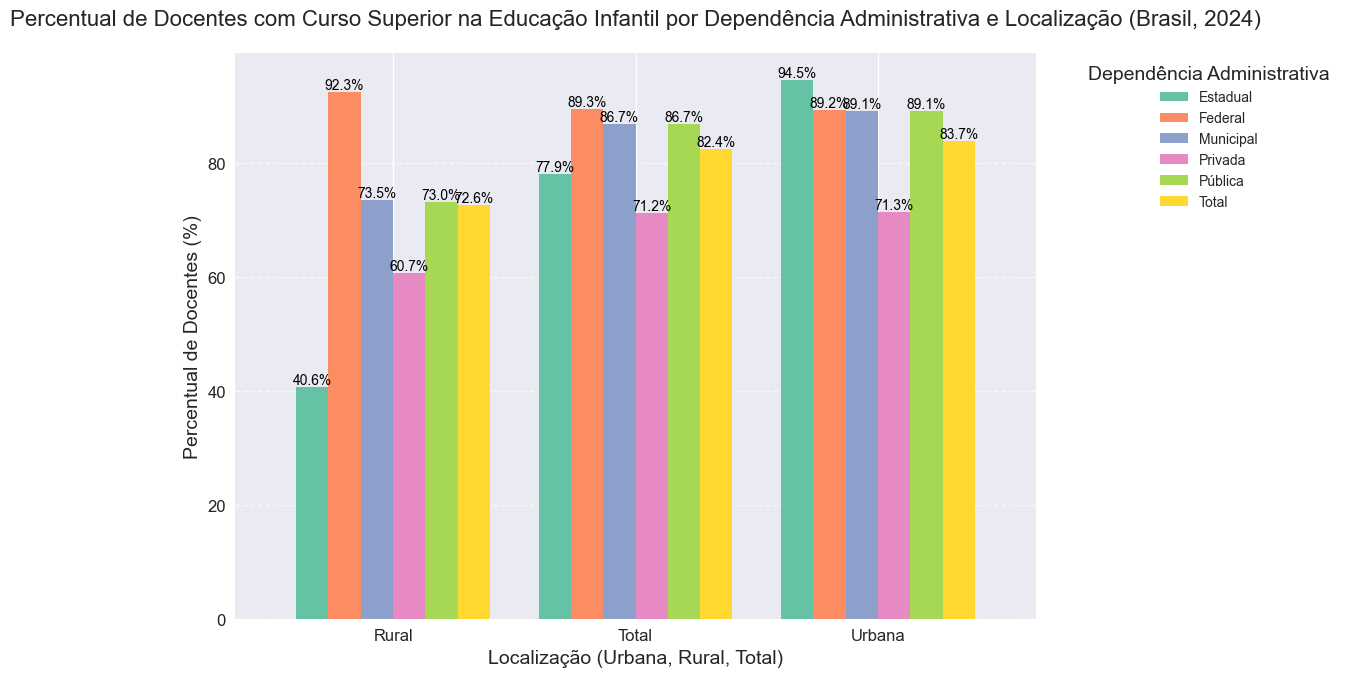

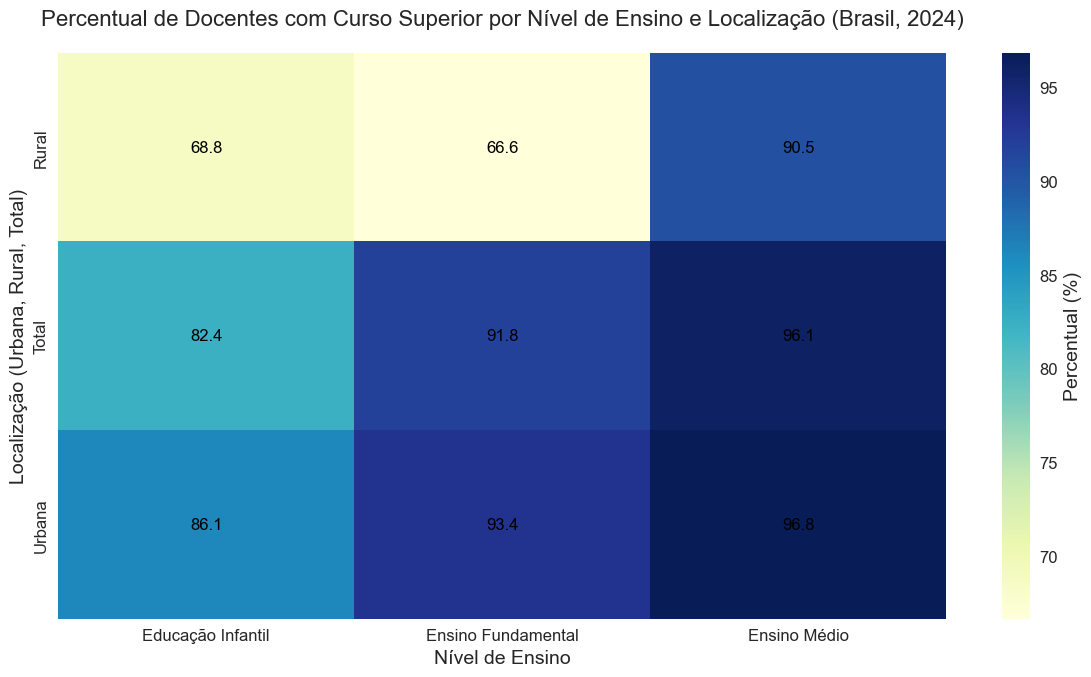

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurando o estilo geral dos gráficos para um visual claro e legível
plt.style.use('seaborn-v0_8')  # Estilo limpo e profissional
sns.set_palette("Set2")  # Paleta de cores suave e distinta
plt.rcParams['font.size'] = 14  # Tamanho da fonte aumentado para legibilidade
plt.rcParams['axes.titlesize'] = 16  # Tamanho do título maior
plt.rcParams['axes.labelsize'] = 14  # Tamanho dos rótulos dos eixos
plt.rcParams['xtick.labelsize'] = 12  # Tamanho dos rótulos dos ticks
plt.rcParams['ytick.labelsize'] = 12  # Tamanho dos rótulos dos ticks
plt.rcParams['figure.figsize'] = (12, 7)  # Tamanho maior para melhor visualização

# 1. Gráfico de Barras Empilhadas: Mostra o percentual de docentes com curso superior por região e nível de ensino
# Objetivo: Comparar como os percentuais variam entre regiões (Brasil, Norte, etc.) para Educação Infantil, Fundamental e Médio
df_regioes = df[df['Unidade_Geografica'].isin(['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']) &
                (df['Localizacao'] == 'Total') &
                (df['Dependencia_Administrativa'] == 'Total')]

# Preparando os dados para o gráfico empilhado
niveis_ensino = ['Educacao_Infantil_Total', 'Ensino_Fundamental_Total', 'Ensino_Medio']
regioes = df_regioes['Unidade_Geografica']
valores = df_regioes[niveis_ensino].values

# Criando o gráfico de barras empilhadas
fig, ax = plt.subplots()
bottom = np.zeros(len(regioes))  # Para empilhar as barras
for i, nivel in enumerate(niveis_ensino):
    bars = ax.bar(regioes, valores[:, i], bottom=bottom, label=nivel.replace('_', ' '))
    # Adicionando valores nas barras para facilitar a leitura
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # Mostrar apenas valores não nulos
            ax.text(bar.get_x() + bar.get_width() / 2, bottom[j] + height / 2,
                    f'{height:.1f}%', ha='center', va='center', fontsize=10, color='black')
    bottom += valores[:, i]

# Personalizando o gráfico
ax.set_title('Percentual de Docentes com Curso Superior por Região e Nível de Ensino (Brasil, 2024)', pad=20)
ax.set_xlabel('Região do Brasil')
ax.set_ylabel('Percentual de Docentes (%)')
ax.legend(title='Nível de Ensino', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Gráfico de Barras Agrupadas: Mostra o percentual de docentes com curso superior na Educação Infantil por dependência administrativa e localização
# Objetivo: Comparar como o percentual varia entre dependências (Federal, Estadual, Municipal, Privada) em áreas Urbanas, Rurais e Totais
df_dep = df[(df['Unidade_Geografica'] == 'Brasil')]

# Preparando os dados para o gráfico de barras agrupadas
pivot_dep = df_dep.pivot_table(index='Localizacao', columns='Dependencia_Administrativa',
                               values='Educacao_Infantil_Total')

# Criando o gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 7))
pivot_dep.plot(kind='bar', ax=ax, width=0.8)

# Adicionando valores no topo de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Mostrar apenas valores não nulos
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black')

# Personalizando o gráfico
ax.set_title('Percentual de Docentes com Curso Superior na Educação Infantil por Dependência Administrativa e Localização (Brasil, 2024)', pad=20)
ax.set_xlabel('Localização (Urbana, Rural, Total)')
ax.set_ylabel('Percentual de Docentes (%)')
ax.legend(title='Dependência Administrativa', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Gráfico de Calor (Heatmap): Mostra o percentual de docentes com curso superior por nível de ensino e localização
# Objetivo: Comparar os percentuais de Educação Infantil, Fundamental e Médio em áreas Urbanas, Rurais e Totais no Brasil
df_brasil = df[df['Unidade_Geografica'] == 'Brasil']

# Preparando os dados para o heatmap
df_brasil_pivot = df_brasil.pivot_table(index='Localizacao',
                                        values=['Educacao_Infantil_Total', 'Ensino_Fundamental_Total', 'Ensino_Medio'],
                                        aggfunc='mean')

# Renomeando colunas para maior clareza
df_brasil_pivot.columns = ['Educação Infantil', 'Ensino Fundamental', 'Ensino Médio']

# Criando o gráfico de calor
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(df_brasil_pivot, annot=True, cmap='YlGnBu', fmt='.1f', cbar_kws={'label': 'Percentual (%)'}, ax=ax,
            annot_kws={'size': 12, 'color': 'black'})

# Personalizando o gráfico
ax.set_title('Percentual de Docentes com Curso Superior por Nível de Ensino e Localização (Brasil, 2024)', pad=20)
ax.set_xlabel('Nível de Ensino')
ax.set_ylabel('Localização (Urbana, Rural, Total)')
plt.tight_layout()
plt.show()


# Exportação para o PowerBI

In [16]:
df.to_csv('docentes_superior_tratado_2024.csv', index=False)
print("Arquivo 'docentes_superior_tratado_2024.csv' exportado com sucesso!")


Arquivo 'docentes_superior_tratado_2024.csv' exportado com sucesso!


# renomeado arquivo

In [17]:
ren DataScience4.ipynb analise_docentes.ipynb

O sistema n�o pode encontrar o arquivo especificado.


# Correção de erros

In [19]:
# Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
plt.rcParams['font.size'] = 14

# Leitura do CSV (ajustado para uso local)
dados = pd.read_csv('docentes_superior_tratado_2024.csv', sep=';', encoding='latin-1')

# Visualização inicial
print(dados.head())
print(dados.info())
print(dados.describe())


  Ano,Unidade_Geografica,Localizacao,Dependencia_Administrativa,Educacao_Infantil_Total,Educacao_Infantil_Creche,Educacao_Infantil_PreEscola,Ensino_Fundamental_Total,Ensino_Fundamental_Anos_Iniciais,Ensino_Fundamental_Anos_Finais,Ensino_Medio,Educacao_Profissional,Educacao_Jovens_Adultos_EJA,Educacao_Especial
0  2024,Brasil,Total,Total,82.4,81.4,83.7,90.4,88...                                                                                                                                                                                                                                                                  
1  2024,Brasil,Total,Federal,89.3,87.7,91.1,98.1,...                                                                                                                                                                                                                                                                  
2  2024,Brasil,Total,Estadual,77.9,62.9,80.1,95.8...               

# Tratamento e análise

In [22]:
print(dados.columns.tolist())


['Ano,Unidade_Geografica,Localizacao,Dependencia_Administrativa,Educacao_Infantil_Total,Educacao_Infantil_Creche,Educacao_Infantil_PreEscola,Ensino_Fundamental_Total,Ensino_Fundamental_Anos_Iniciais,Ensino_Fundamental_Anos_Finais,Ensino_Medio,Educacao_Profissional,Educacao_Jovens_Adultos_EJA,Educacao_Especial']


In [24]:
dados = pd.read_csv('docentes_superior_tratado_2024.csv', sep=';', engine='python')
print(dados.columns.tolist())


['Ano,Unidade_Geografica,Localizacao,Dependencia_Administrativa,Educacao_Infantil_Total,Educacao_Infantil_Creche,Educacao_Infantil_PreEscola,Ensino_Fundamental_Total,Ensino_Fundamental_Anos_Iniciais,Ensino_Fundamental_Anos_Finais,Ensino_Medio,Educacao_Profissional,Educacao_Jovens_Adultos_EJA,Educacao_Especial']


In [1]:
import pandas as pd

# Ler o arquivo original
df = pd.read_csv("docentes_superior_tratado_2024.csv")

# Remover linhas onde a coluna 'Ano' não é numérica
df = df[pd.to_numeric(df["Ano"], errors="coerce").notnull()]

# Salvar novo arquivo
df.to_csv("docentes_superior_tratado_2024_corrigido.csv", index=False)
